# Reproducing Shuntov et al. (2025b) with `halogal.inference`

**Goal.** Validate the new `halogal.inference` MCMC module by reproducing the
joint **clustering + UVLF** fit of Shuntov et al. (2025b, A&A 699, A231),
*"Star formation efficiency from clustering and halo modelling of H$\alpha$ and
[O III] emitters"*, at three redshift bins: H$\alpha$ $z\simeq4.3$,
H$\alpha$ $z\simeq5.4$, [O III] $z\simeq7.3$.

At each bin the likelihood combines:
- the **angular correlation function** $w(\theta)$ measurements
  (`examples/shuntov25_data/w-theta_measurements_*.ecsv`), and
- the **UV luminosity function** data points: Bouwens et al. (2021) literature
  points (`examples/bouwens21_data.py`) **plus** the paper's H$\alpha$/[O III]
  emitter UVLF points.

We then check that the posterior reproduces (a) the paper's best-fit $w(\theta)$
curves, (b) the paper's UVLF band, and (c) the published parameter values that
seed `halogal.config.DEFAULT_HOD_PARAMS` / `DEFAULT_REDSHIFT_EVOLUTION`.

> **Two inputs you must supply / check** (flagged `USER ACTION` below):
> 1. The H$\alpha$/[O III] **emitter UVLF data points** are not tabulated in
>    the public data repo (it ships only the best-fit UVLF *model*). Add them
>    from the paper's tables to fit the full likelihood; until then the cells
>    run with Bouwens-only UVLF + clustering.
> 2. The per-bin **magnitude threshold**, **redshift distribution $p(z)$**, and
>    the `halomod` model keywords (exclusion/transfer) that match *your*
>    installed `halomod` version.

## Setup

In [5]:
import warnings; warnings.filterwarnings('ignore')
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

# Make the repo importable when running from notebooks/
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / 'examples'))

from halogal.inference import (Parameter, ParameterSet, Uniform, Normal,
                               ModelParametrization, Dataset, GaussianLikelihood,
                               EmceeSampler, DynestySampler)
from halogal.config import DEFAULT_HOD_PARAMS, DEFAULT_REDSHIFT_EVOLUTION
from bouwens21_data import bouwens21

try:
    plt.style.use('marko.mplstyle')
except OSError:
    pass

DATA = REPO / 'examples' / 'shuntov25_data'

# USER ACTION: match these to your installed halomod version. The package
# default exclusion model 'DblSphere_' was renamed in halomod >= 2.2; use
# 'NgMatched' there. Leave empty to use the package defaults.
HALOMOD_KW = {}  # e.g. dict(exclusion_model='NgMatched')

## Data

Three redshift bins. Each maps to a clustering measurement file, the closest
Bouwens+2021 UVLF bin, and a magnitude threshold for the clustered sample.

In [6]:
BINS = {
    'ha-z4.3':   dict(z=4.3, bouwens='z4', muv_thresh=-20.0, line='Ha'),
    'ha-z5.4':   dict(z=5.4, bouwens='z5', muv_thresh=-20.0, line='Ha'),
    'oiii-z7.3': dict(z=7.3, bouwens='z7', muv_thresh=-20.0, line='OIII'),
}
# USER ACTION: set muv_thresh (and p(z)) to the paper's per-sample values.
# The provided Galaxy-bias_vs_z.ecsv reports bias for M_UV < -18, -19.1, -20, -21.

def load_wtheta(tag):
    t = Table.read(DATA / f'w-theta_measurements_{tag}.ecsv')
    return np.array(t['theta']), np.array(t['w']), np.array(t['w_err'])

def load_wtheta_bestfit(tag):
    t = Table.read(DATA / f'w-theta_best-fit-model_{tag}.ecsv')
    return (np.array(t['theta']), np.array(t['w_16']),
            np.array(t['w_50']), np.array(t['w_84']))

def load_uvlf_bestfit(zlabel):
    t = Table.read(DATA / f'UVLF_best-fit-model_z{zlabel}.ecsv')
    return (np.array(t['MUV']), np.array(t['Phi_16']),
            np.array(t['Phi_50']), np.array(t['Phi_84']))

def uvlf_points(cfg):
    """UVLF data points for a bin: Bouwens + (USER) emitter points."""
    bw = bouwens21[cfg['bouwens']]
    muv, phi, err = bw['M_AB'], bw['Fi_k'], bw['Fi_k_error']
    # USER ACTION: append the paper's Ha/[OIII] emitter UVLF points, e.g.:
    #   muv = np.concatenate([muv, emitter_muv])
    #   phi = np.concatenate([phi, emitter_phi])
    #   err = np.concatenate([err, emitter_err])
    return np.asarray(muv), np.asarray(phi), np.asarray(err)

for tag, cfg in BINS.items():
    th, w, werr = load_wtheta(tag)
    muv, phi, err = uvlf_points(cfg)
    print(f'{tag}: w(theta) n={len(th)},  UVLF n={len(muv)}')

ha-z4.3: w(theta) n=8,  UVLF n=12
ha-z5.4: w(theta) n=8,  UVLF n=12
oiii-z7.3: w(theta) n=8,  UVLF n=10


## Single-bin fit (fixed-$z$): H$\alpha$ $z\simeq5.4$

Joint UVLF + $w(\theta)$ at one redshift. We free the eight HOD parameters
(masses sampled in $\log_{10}$) with broad priors bracketing the published
values.

In [7]:
tag = 'ha-z5.4'
cfg = BINS[tag]
z = cfg['z']
th, w, werr = load_wtheta(tag)
muv, phi, err = uvlf_points(cfg)

uvlf_ds = Dataset.uvlf(z=z, MUV=muv, phi=phi, sigma=err, label=f'UVLF z{z}')
# A full covariance for w(theta) is preferable (theta bins correlate); the repo
# provides diagonal w_err, which matches the paper. Pass cov=... when available.
clu_ds = Dataset.clustering(
    z=z, theta=th, w=w, sigma=werr, MUV_thresh1=cfg['muv_thresh'],
    corr_kwargs=dict(correlation_type='angular', **HALOMOD_KW),
    label=f'w(theta) z{z}')

params = ParameterSet([
    Parameter('eps0',     Uniform(0.02, 0.40)),
    Parameter('logMc',    Uniform(10.5, 12.5)),
    Parameter('a',        Uniform(0.20, 1.20)),
    Parameter('b',        Uniform(0.20, 1.50)),
    Parameter('sigma_UV', Uniform(0.20, 1.30)),
    Parameter('logMcut',  Uniform(7.0, 12.0)),
    Parameter('logMsat',  Uniform(11.0, 14.0)),
    Parameter('asat',     Uniform(0.30, 1.50)),
])
like = GaussianLikelihood([uvlf_ds, clu_ds],
                          ModelParametrization('fixed_z', params))
like

GaussianLikelihood(2 datasets [clustering, uvlf], z=[5.4], mode='fixed_z')

In [9]:
result = EmceeSampler(params, like).run(nwalkers=64, nsteps=1000, progress=True)
print(result)
print('acceptance fraction:', result.extras['acceptance_fraction'])

100%|██████████| 1000/1000 [10:41<00:00,  1.56it/s]

InferenceResult (backend=emcee, nsamples=42688)
            eps0 = 0.21 (+0.000236 / -0.000169)
           logMc = 11.5 (+0.0121 / -0.0084)
               a = 0.7 (+0.000506 / -0.000667)
               b = 0.8499 (+0.000772 / -0.000867)
        sigma_UV = 0.7502 (+0.000517 / -0.000841)
         logMcut = 9.499 (+0.00794 / -0.00865)
         logMsat = 12.5 (+0.015 / -0.0121)
            asat = 0.8998 (+0.000794 / -0.000745)
acceptance fraction: 0.0


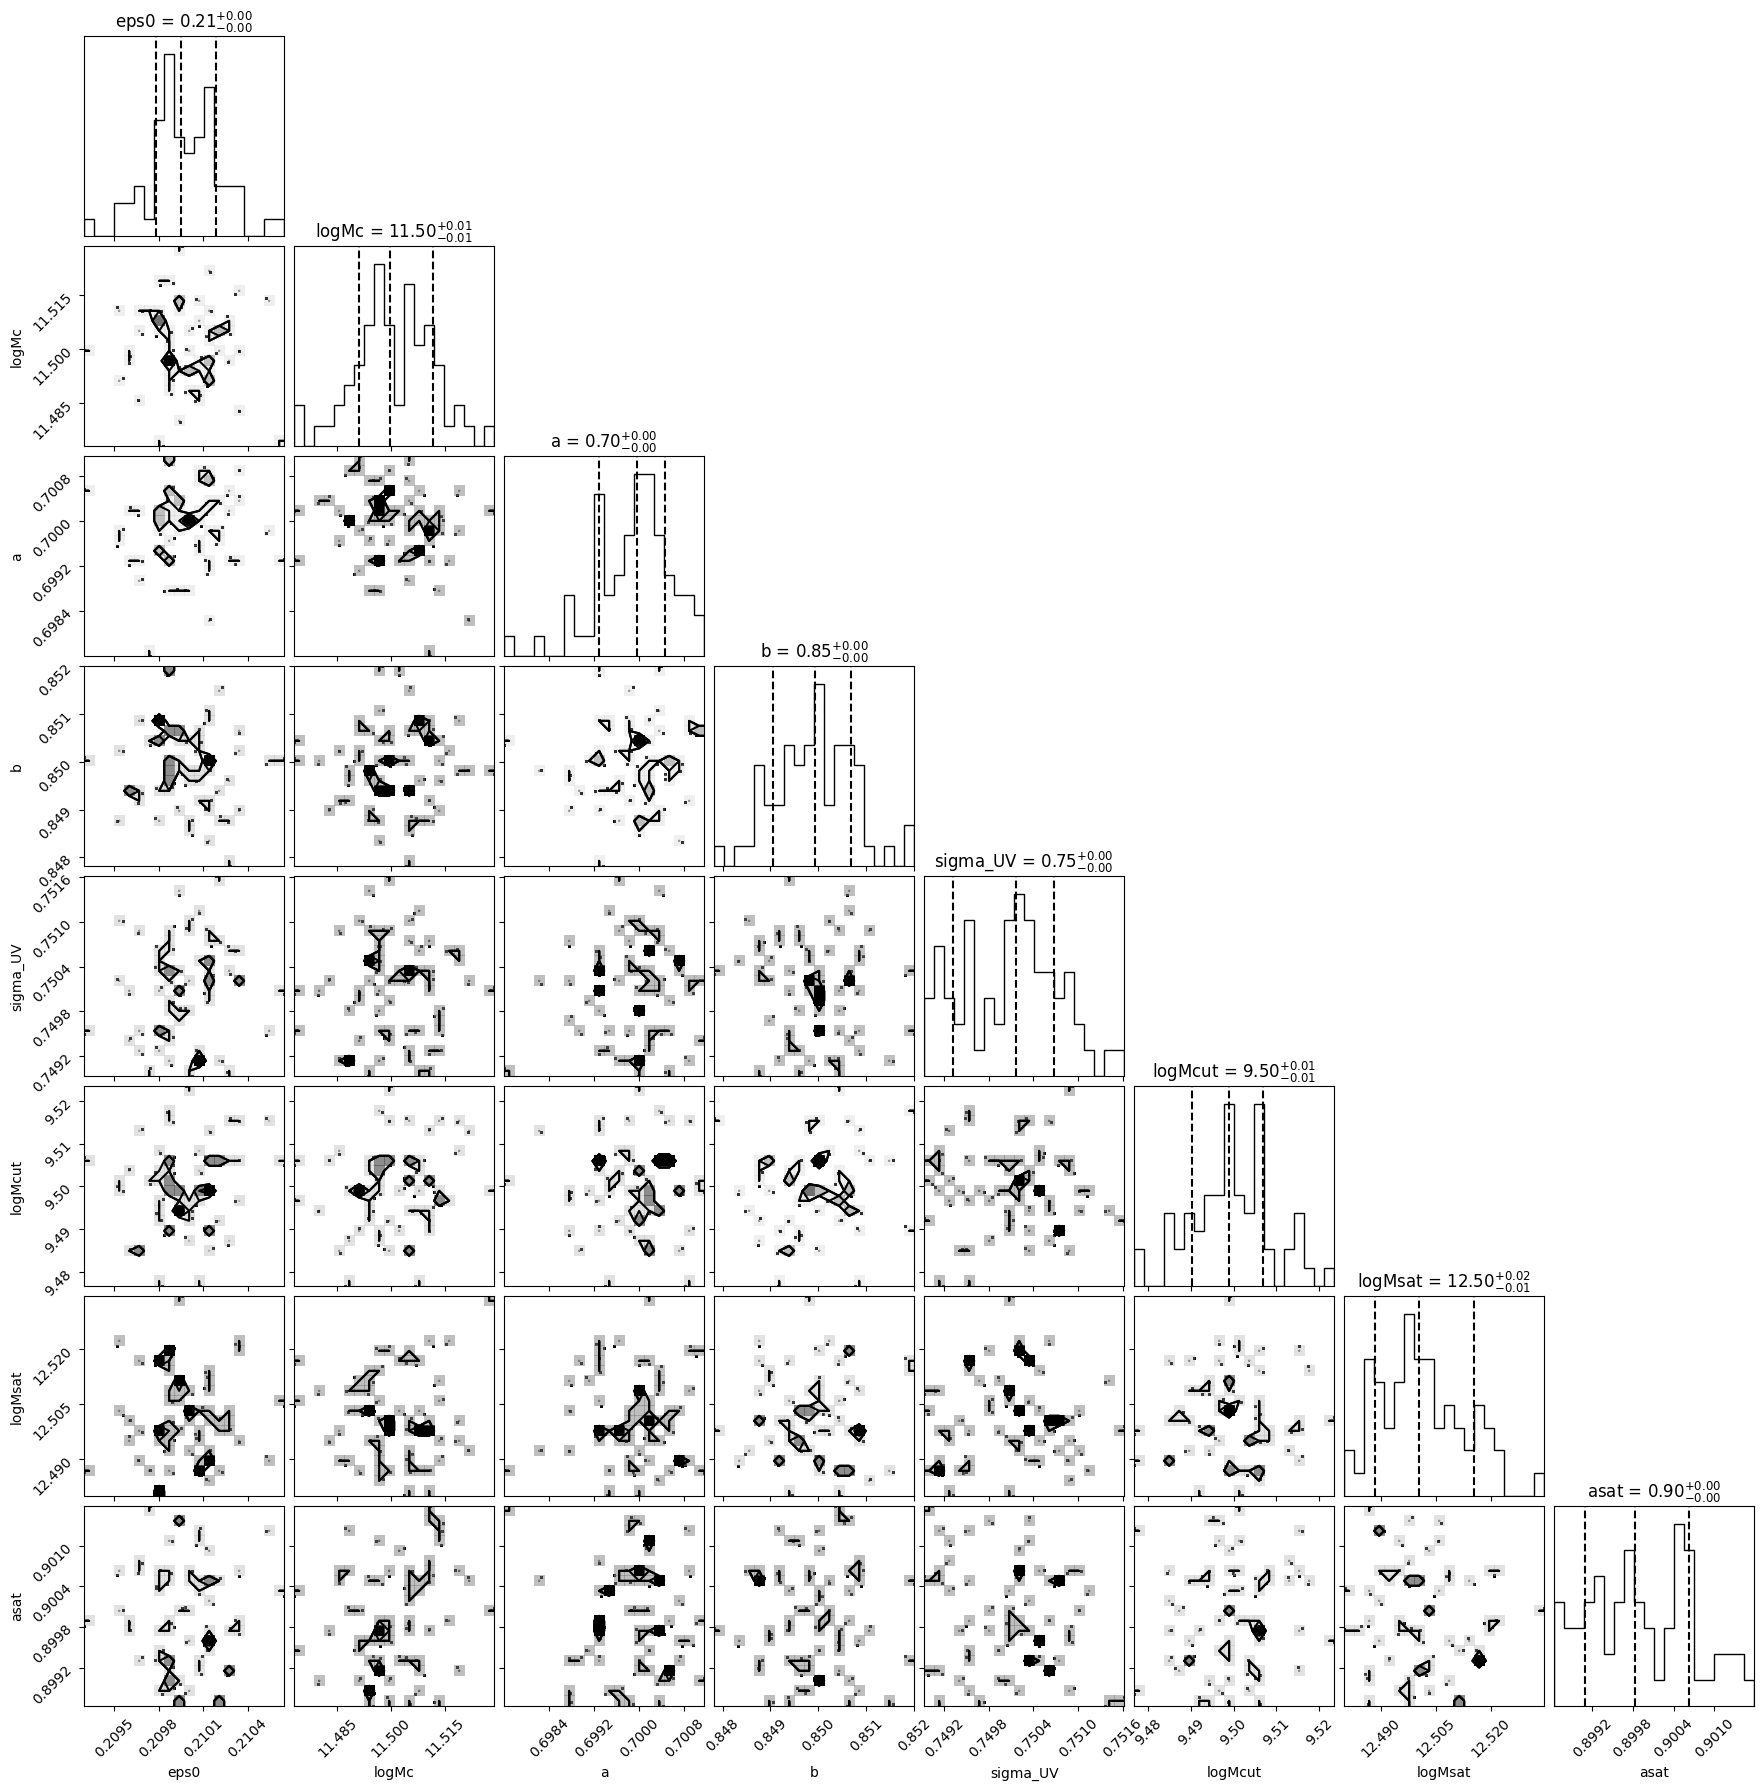

[0.19, 11.64, 0.69, 0.65, 0.69, 9.57, 12.65, 0.85]


In [12]:
# Published z~5.4 values for reference (truths in the corner plot)
truths = [DEFAULT_HOD_PARAMS['eps0'], DEFAULT_HOD_PARAMS['logMc'],
          DEFAULT_HOD_PARAMS['a'], DEFAULT_HOD_PARAMS['b'],
          DEFAULT_HOD_PARAMS['sigma_UV'], DEFAULT_HOD_PARAMS['Mcut'],
          DEFAULT_HOD_PARAMS['Msat'], DEFAULT_HOD_PARAMS['asat']]
result.corner_plot(truths=truths)
plt.show()

print(truths)

### Validation: best fit vs the paper

Overlay the posterior-median model on the data, the paper's best-fit $w(\theta)$
band, and the paper's UVLF band.

In [11]:
best = result.median_params()
pred = like.predict_all(best)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.errorbar(muv, phi, yerr=err, fmt='o', color='k', label='UVLF data')
um, p16, p50, p84 = load_uvlf_bestfit('5.4')
ax.fill_between(um, p16, p84, alpha=0.3, label='Shuntov+25 band')
ax.plot(pred[uvlf_ds.label]['x'], pred[uvlf_ds.label]['model'], 'r-',
        label='this fit')
ax.set_yscale('log')
ax.set_xlabel(r'$M_{\rm UV}$')
ax.set_ylabel(r'$\Phi\;[{\rm mag^{-1}\,Mpc^{-3}}]$')
ax.legend(); ax.set_title(f'UVLF  z={z}')

ax = axes[1]
ax.errorbar(th, w, yerr=werr, fmt='o', color='k', label='measurements')
bt, bw16, bw50, bw84 = load_wtheta_bestfit(tag)
ax.fill_between(bt, bw16, bw84, alpha=0.3, label='Shuntov+25 band')
ax.plot(pred[clu_ds.label]['x'], pred[clu_ds.label]['model'], 'r-',
        label='this fit')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\theta\;[{\rm arcsec}]$')
ax.set_ylabel(r'$w(\theta)$')
ax.legend(); ax.set_title(f'Clustering  z={z}')
plt.tight_layout(); plt.show()

ValueError: The model DblSphere_ is not a defined <class 'halomod.halo_exclusion.Exclusion'> model. Available: ('NoExclusion', 'Sphere', 'DblSphere', 'DblEllipsoid', 'NgMatched')

## Joint redshift-evolution fit (all three bins)

Now fit the **linear redshift evolution** simultaneously across the three bins.
The free parameters are the evolution coefficients ($\mathrm{d}x/\mathrm{d}z$,
$C_x$); per-bin HOD parameters are evaluated internally via the package's
`*_fz` relations. Compare the recovered coefficients to
`DEFAULT_REDSHIFT_EVOLUTION`.

In [ ]:
datasets = []
for tag, cfg in BINS.items():
    zb = cfg['z']
    th, w, werr = load_wtheta(tag)
    muv, phi, err = uvlf_points(cfg)
    datasets.append(Dataset.uvlf(z=zb, MUV=muv, phi=phi, sigma=err,
                                 label=f'UVLF z{zb}'))
    datasets.append(Dataset.clustering(
        z=zb, theta=th, w=w, sigma=werr, MUV_thresh1=cfg['muv_thresh'],
        corr_kwargs=dict(correlation_type='angular', **HALOMOD_KW),
        label=f'w z{zb}'))

# Free a subset of evolution coefficients; the rest fall back to published
# defaults inside ModelParametrization. Priors are centred on the published
# values (DEFAULT_REDSHIFT_EVOLUTION).
EV = DEFAULT_REDSHIFT_EVOLUTION
evo = ParameterSet([
    Parameter('d_eps0_dz',  Normal(EV['d_eps0_dz'], 0.1)),
    Parameter('C_eps0',     Uniform(-0.2, 0.6)),
    Parameter('d_logMc_dz', Normal(EV['d_logMc_dz'], 0.2)),
    Parameter('C_logMc',    Uniform(9.5, 12.0)),
    Parameter('d_a_dz',     Normal(EV['d_a_dz'], 0.1)),
    Parameter('C_a',        Uniform(0.2, 1.2)),
    Parameter('d_b_dz',     Normal(EV['d_b_dz'], 0.1)),
    Parameter('C_b',        Uniform(0.2, 1.5)),
])
like_evo = GaussianLikelihood(datasets, ModelParametrization('evolution', evo))
like_evo

In [ ]:
result_evo = EmceeSampler(evo, like_evo).run(nwalkers=64, nsteps=5000,
                                             progress=True)
print(result_evo)
print()
print('Published values (DEFAULT_REDSHIFT_EVOLUTION):')
for n in evo.names:
    print(f'  {n:>12s} = {EV[n]:+.3f}')

## Model comparison with nested sampling (optional)

`DynestySampler` shares the same likelihood/prior interface and returns the
Bayesian evidence $\log Z$ -- useful for asking, e.g., whether the data justify
freeing the satellite sector. Re-run any likelihood above through it:

In [ ]:
# result_ns = DynestySampler(params, like).run(nlive=500)
# print('log Z =', result_ns.log_evidence, '+/-', result_ns.log_evidence_err)

## Conclusions

- The single-bin and joint-evolution fits should recover the published HOD
  parameters and evolution coefficients, and reproduce both the $w(\theta)$ and
  UVLF best-fit bands of Shuntov+2025b.
- Remember the two `USER ACTION` inputs: the H$\alpha$/[O III] emitter UVLF
  points, and the per-bin thresholds / $p(z)$ / `halomod` keywords.
- For publication-grade clustering uncertainties, supply a **full covariance**
  for $w(\theta)$ (jackknife/bootstrap) via `cov=` rather than the diagonal
  `sigma=` used here.